# Лабораторная работа

В данной работе мы с вами попробуем применить рекуррентные сети к задаче предсказания цены акций компании Microsoft.

В данном ноутбуке вы найдете частично готовый к применению код, некоторые элементы которого пропущены и вместо них стоит заглушка "\<ENTER YOUR CODE HERE>". Это означает, что вместо этой заглушки вам необходимо написать собственный код, решающий какую-то конкретную подзадачу. Детали вы найдете в комментариях около каждого из таких мест.
    
Давайте убедимся, что у нас установлены все необходимые библиотеки.

In [1]:
!pip install numpy matplotlib tensorflow

Для воспроизводимости зафиксируем генераторы случайных чисел.

In [3]:
seed_value = 0

import os
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)  # для TF2 вместо tf.compat.v1.set_random_seed

# Для дополнительной детерминированности (опционально)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

Импортируем все необходимые библиотеки.

In [4]:
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

Для начала нам необходимо прочитать набор данных. Вместе с данным ноутбуком вы найдете файл MSFT_corrupted.csv. Прочитайте и запишите его в фрейм.

In [6]:
df_dirty = pd.read_csv('MSFT_corrupted.csv')

Давайте выведем первые несколько строк файла.

In [7]:
df_dirty.head()

,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT


Судя по названию файла, в нем могут присутствовать проблемы с данными. Давайте проверим данные на наличие NaN и каким-либо образом восстановим пропущенные значения.

In [8]:
# Проверяем количество пропущенных значений в каждом столбце
print(df_dirty.isna().sum())

# Восстанавливаем пропуски: для ценовых столбцов используем метод forward fill (заполняем предыдущим значением)
price_cols = ['open', 'high', 'low', 'close']
df_dirty[price_cols] = df_dirty[price_cols].fillna(method='ffill')

# Удаляем строки, в которых всё ещё остались NaN (если такие есть)
df = df_dirty.dropna().reset_index(drop=True)

date      0
open      5
high      5
low       5
close     5
volume    0
Name      0
dtype: int64


/tmp/ipykernel_7395/42209577.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_dirty[price_cols] = df_dirty[price_cols].fillna(method='ffill')


В данной работе мы с вами будем предсказывать стоимость акции на момент закрытия дня (колонка 'close'). Давайте построим график этой колонки.

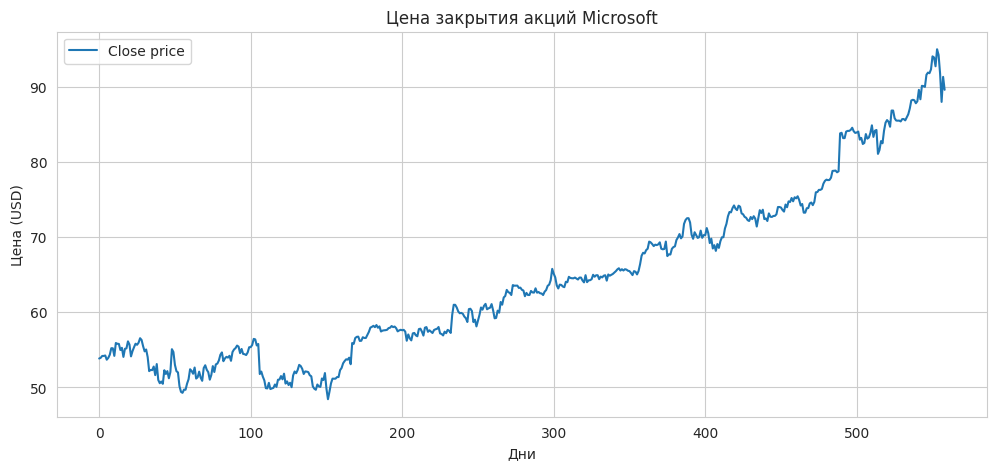

In [9]:
# Строим график цены закрытия
plt.figure(figsize=(12,5))
plt.plot(df['close'], label='Close price')
plt.title('Цена закрытия акций Microsoft')
plt.xlabel('Дни')
plt.ylabel('Цена (USD)')
plt.legend()
plt.show()

Оставим в нашем датафрейме только необходимую нам колонку.

In [10]:
# Выделяем только столбец 'close' для дальнейшей работы
train_df = df[['close']].copy()

Итак, теперь давайте подготовим все необходимое для начала обучения. Зададим глобальные константы - количества эпох, дней и коэффициент деления массива.

In [11]:
EPOCHS = 10  # количество эпох для обучения
DAYS = 10    # на сколько дней назад смотреть при обучении
SPLIT_VALUE = 0.95  # как делить массив

Определим константу для разделения массива на тренировочную и тестовую части.

In [12]:
training_data_len = int(len(train_df) * SPLIT_VALUE)
training_data_len

531

Далее с помощью MinMaxScaler'а приведем данные к значениям на отрезке \[0, 1]

In [13]:
# Инициализируем MinMaxScaler и масштабируем данные
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(train_df)

Давайте создадим тренировочный набор данных. Набор будет выглядеть следующим образом: мы будем брать данные за последние X дней и формировать из этого вектор X, а вектор Y будет являться значением стоимости акции на следующий день

In [14]:
train_data = scaled_data[:training_data_len, :]

x_train = []
y_train = []

for i in range(DAYS, len(train_data)):
    x_train.append(train_data[i-DAYS:i])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

Создадим модель для предсказания. Первым слоем модели должен являться рекуррентный слой с соответствующей формой входного тензора, последним - полносвязный слой с единственным нейроном для предсказания результата.

In [15]:
model = Sequential()
# Добавляем LSTM слой с 50 нейронами; входная форма: (DAYS, 1) - т.к. у нас один признак (close)
model.add(LSTM(50, return_sequences=False, input_shape=(DAYS, 1)))
# Выходной полносвязный слой с одним нейроном для предсказания
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.fit(x_train, y_train, batch_size=1, epochs=EPOCHS)

Epoch 1/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0031
Epoch 2/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0010
Epoch 3/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.8287e-04
Epoch 4/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.8718e-04
Epoch 5/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.0704e-04
Epoch 6/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.3769e-04
Epoch 7/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7696e-04
Epoch 8/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.2412e-04
Epoch 9/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.7965e-04
Epoch 10/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.4437e-04


Для тестирования нашей модели давайте таким же образом сформируем тестовый датасет.

In [17]:
test_data = scaled_data[training_data_len - DAYS: , :]

x_test = []
y_test = []
for i in range(DAYS, len(test_data)):
    # Берём последовательность из DAYS предыдущих значений
    x_test.append(test_data[i-DAYS:i])
    # Целевое значение - текущее значение close
    y_test.append(test_data[i, 0])

# Преобразуем в numpy-массивы и изменяем форму для LSTM: (samples, DAYS, 1)
x_test = np.array(x_test).reshape(-1, DAYS, 1)
y_test = np.array(y_test)

Давайте получим предсказания модели и визуализируем результат.

In [18]:
predictions = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


/tmp/ipykernel_7395/523100001.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = scaler.inverse_transform(predictions)


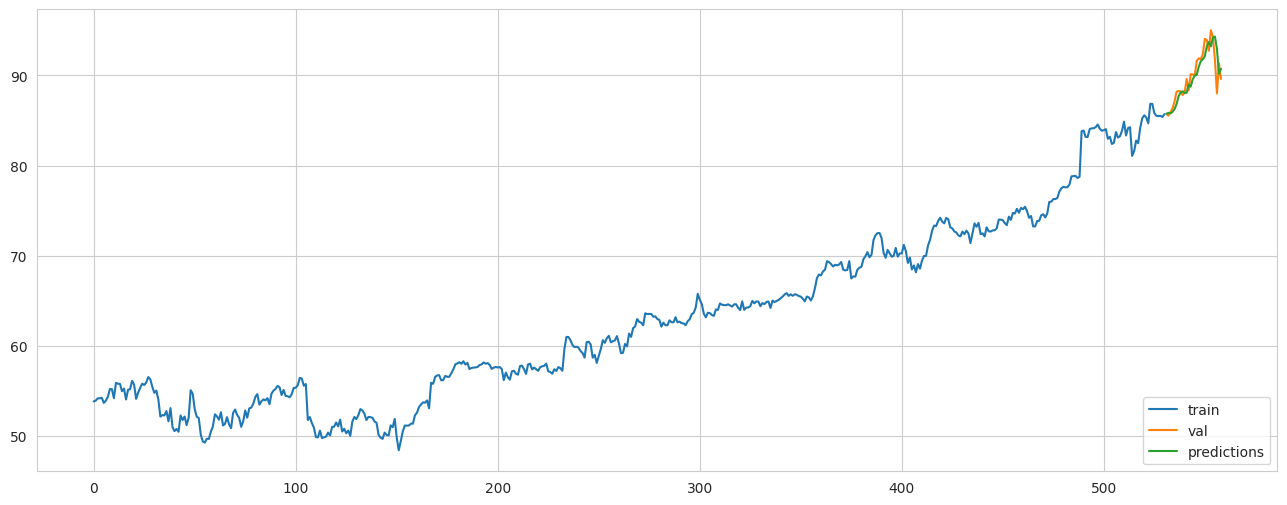

In [19]:
train = train_df[:training_data_len]
valid = train_df[training_data_len:]
valid['predictions'] = scaler.inverse_transform(predictions)
plt.figure(figsize=(16,6))
plt.plot(train['close'])
plt.plot(valid[['close', 'predictions']])
plt.legend(['train', 'val', 'predictions'], loc='lower right')

В качестве бейзлайна (т.е. базовой просто модели для сравнения) выберем step-1 модель. Данная модель для дня i просто берет значение дня i-1. Реализуйте такую модель и в массив prediction_step запишите ее результаты для тех же данных.

In [22]:
# Step-1 baseline: предсказание = предыдущее истинное значение
last_train_close = train['close'].iloc[-1]
predictions_step = np.concatenate(([last_train_close], valid['close'].values[:-1]))
# Приводим к двумерной форме, как у predictions
predictions_step = predictions_step.reshape(-1, 1)

In [23]:
assert predictions.shape == predictions_step.shape

Построим график нашей модели и step-1 модели.

/tmp/ipykernel_7395/1478130906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_step'] = predictions_step


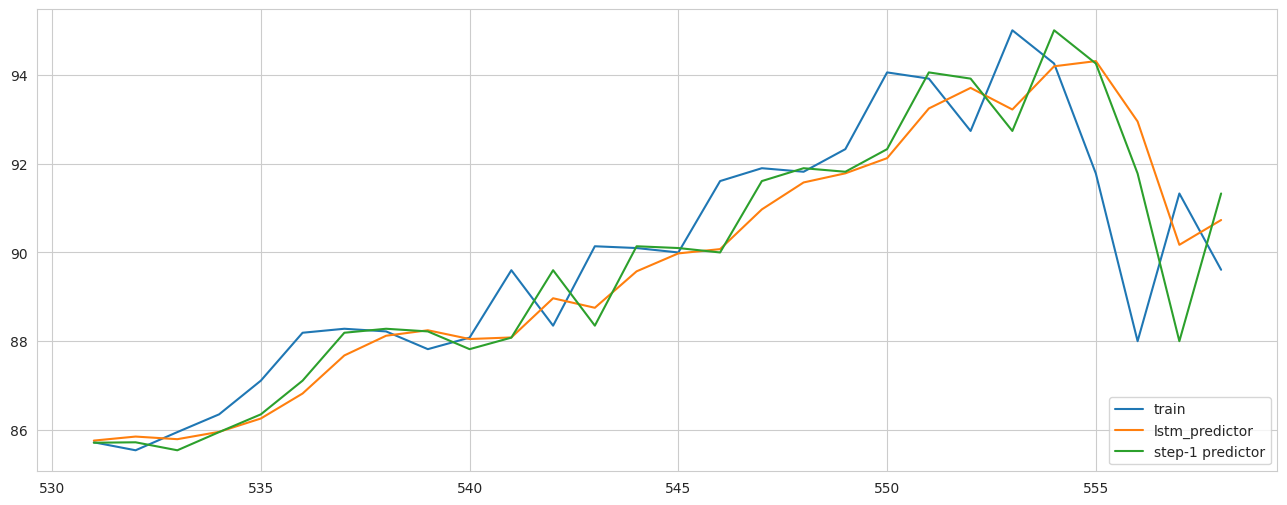

In [24]:
valid['predictions_step'] = predictions_step
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_step']])
plt.legend(['train', 'lstm_predictor', 'step-1 predictor'], loc='lower right')

Удалось ли вам добиться хороших результатов модели? Попробуйте поменять модель нейронной сети, количество слоев, и другие гиперпараметры.  

В процессе тестирования нашей модели мы, тем не менее, использовали "настоящие" данные каждый день для предсказания следующего дня. Давайте попробуем предсказать `len(valid)` дней (т.е. столько же, какова длина массива тестирования) обладая лишь данными на момент дня начала тестирования.  

Т.е. каждый шаг алгоритму необходимо подавать данные за последние DAYS дней, получать его предсказание и записывать в массив с данными как результат дня $i$. На следующем шаге в качестве данных уже будут данные за последние DAYS-1 дней и день $i$, а результат будет записан в день $i+1$ и так далее. Конечным итогом станет то, что мы сможем предсказать движение акций на несколько дней вперед.

In [25]:
# Берём последние DAYS масштабированных значений из обучающей выборки в виде списка
x_test_independent = scaled_data[training_data_len - DAYS: training_data_len, 0].tolist()

# Массив для хранения предсказаний (в масштабированном виде)
indep_predictions_scaled = []

for i in range(len(valid)):
    # Берём последние DAYS значений из текущего окна
    current_input = np.array(x_test_independent[-DAYS:]).reshape(1, DAYS, 1)
    # Получаем предсказание модели
    result = model.predict(current_input, verbose=0)[0,0]
    indep_predictions_scaled.append(result)
    # Добавляем предсказанное значение в конец окна для следующего шага
    x_test_independent.append(result)

# Обратное масштабирование предсказаний
valid['predictions_indep'] = scaler.inverse_transform(np.array(indep_predictions_scaled).reshape(-1,1))

/tmp/ipykernel_7395/1917678127.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_indep'] = scaler.inverse_transform(np.array(indep_predictions_scaled).reshape(-1,1))


Давайте построим график и посмотрим на результат, а также сравним его с результатом, когда нам известна настоящая информация за указанные дни.

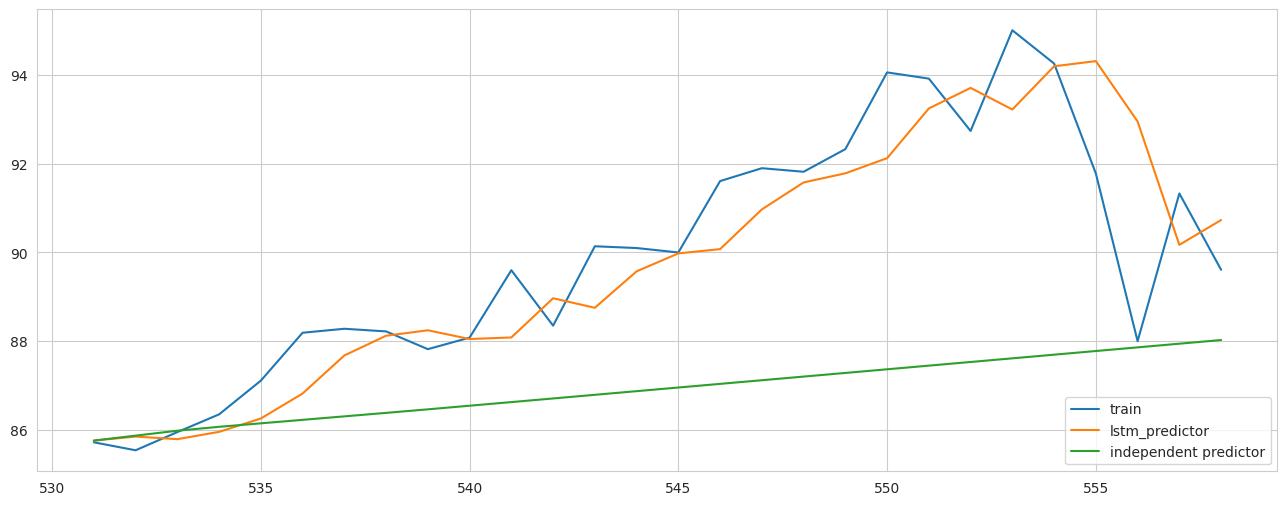

In [27]:
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_indep']])
plt.legend(['train', 'lstm_predictor', 'independent predictor'], loc='lower right')

Как можно заметить, результат оставляет желать лучшего. Рекуррентные модели склонны не учитывать тренд и фиксироваться на какой-либо точке.  

Вашим дальнейшим заданием будет следующее.  
В процессе анализа стоимости акций важным параметром является Moving Average - средняя стоимость акций за последние N дней. Вам необходимо вычислить MA за последние 7, 14 и 28 дней и добавить их как отдельные столбцы к тренировочным данным. После чего - натренировать новую нейронную сеть, которая будет получать MA 7, 14, 28 как входные данные и пытаться предсказывать их значения.

В конце точно так же сравните полученный результат с step-1 моделью и попробуйте построить предсказания из единственной точки. Сможет ли Moving Average исправить проблемы тренда за счет более гладких и усредненных результатов?

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0025
Epoch 2/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0011
Epoch 3/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.7010e-04
Epoch 4/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.3844e-04
Epoch 5/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.3081e-04
Epoch 6/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.3553e-04
Epoch 7/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.5244e-04
Epoch 8/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.9123e-04
Epoch 9/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.5223e-04
Epoch 10/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.2932e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


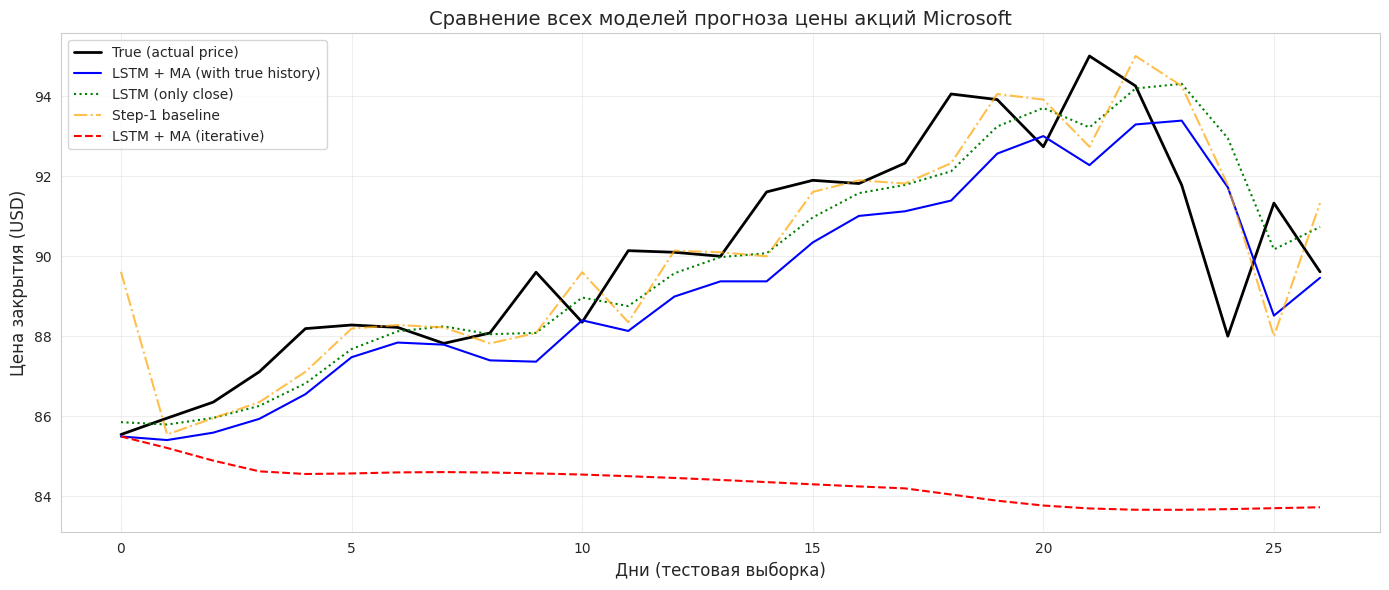

In [29]:
# --- Часть со скользящими средними (MA) ---

# 1. Создаём копию исходного DataFrame (с колонкой close)
df_ma = df[['close']].copy()

# 2. Вычисляем скользящие средние за 7, 14 и 28 дней
df_ma['MA7'] = df_ma['close'].rolling(window=7).mean()
df_ma['MA14'] = df_ma['close'].rolling(window=14).mean()
df_ma['MA28'] = df_ma['close'].rolling(window=28).mean()

# Из-за rolling в первых строках появляются NaN, удаляем их
df_ma = df_ma.dropna().reset_index(drop=True)

# 3. Масштабируем все признаки (close + три MA) - используем .values, чтобы избежать ошибки с именами
scaler_ma = MinMaxScaler(feature_range=(0,1))
scaled_ma = scaler_ma.fit_transform(df_ma.values)  # <- важно: .values

# 4. Разделяем на обучающую и тестовую выборки (по тому же принципу SPLIT_VALUE)
train_len_ma = int(len(df_ma) * SPLIT_VALUE)
train_ma = scaled_ma[:train_len_ma, :]
test_ma = scaled_ma[train_len_ma - DAYS:, :]

# 5. Формируем последовательности для LSTM (вход: DAYS дней по 4 признака)
x_train_ma, y_train_ma = [], []
for i in range(DAYS, len(train_ma)):
    x_train_ma.append(train_ma[i-DAYS:i, :])   # все признаки
    y_train_ma.append(train_ma[i, 0])          # предсказываем close
x_train_ma = np.array(x_train_ma)
y_train_ma = np.array(y_train_ma)

# 6. Строим модель LSTM с многомерным входом
model_ma = Sequential()
model_ma.add(LSTM(50, return_sequences=False, input_shape=(DAYS, x_train_ma.shape[2])))
model_ma.add(Dense(1))
model_ma.compile(optimizer='adam', loss='mean_squared_error')
model_ma.summary()

# 7. Обучаем модель
model_ma.fit(x_train_ma, y_train_ma, batch_size=1, epochs=EPOCHS, verbose=1)

# 8. Тестируем на тестовой выборке (с истинными MA)
x_test_ma = []
for i in range(DAYS, len(test_ma)):
    x_test_ma.append(test_ma[i-DAYS:i, :])
x_test_ma = np.array(x_test_ma)

pred_ma_scaled = model_ma.predict(x_test_ma)
# Обратное масштабирование (восстанавливаем только close) - теперь scaler_ma работает с numpy, ошибок не будет
dummy = np.zeros((len(pred_ma_scaled), scaled_ma.shape[1]))
dummy[:, 0] = pred_ma_scaled.flatten()
pred_ma = scaler_ma.inverse_transform(dummy)[:, 0]

# Визуализация
valid_ma = df_ma[train_len_ma:].copy()
valid_ma['predictions_ma'] = pred_ma

# 9. Подготовка step-1 baseline для тестовой выборки (двумерный массив)
# Берём последнее значение из обучающей выборки и сдвигаем истинные значения
last_train_close = train_df['close'].iloc[-1]
step1_vals = np.concatenate(([last_train_close], valid_ma['close'].values[:-1]))
step1_vals = step1_vals.reshape(-1, 1)  # приводим к двумерной форме

# 10. Единый график сравнения всех моделей
plt.figure(figsize=(14,6))

# Истинные значения
plt.plot(valid_ma['close'].values, label='True (actual price)', linewidth=2, color='black')

# LSTM+MA с истинной историей
plt.plot(valid_ma['predictions_ma'].values, label='LSTM + MA (with true history)', linestyle='-', color='blue')

# LSTM+MA итеративный (будет построен ниже, пока заглушка)
# Базовая LSTM (без MA) – обрезаем до длины valid_ma, если есть
if 'predictions' in valid.columns:
    lstm_only = valid['predictions'].values[-len(valid_ma):]
    plt.plot(lstm_only, label='LSTM (only close)', linestyle=':', color='green')

# Step-1 baseline
plt.plot(step1_vals, label='Step-1 baseline', linestyle='-.', color='orange', alpha=0.7)

# Теперь построим итеративный прогноз LSTM+MA
initial_data = df_ma.iloc[train_len_ma - DAYS : train_len_ma].copy()
initial_scaled = scaler_ma.transform(initial_data.values)  # используем .values

current_window = initial_scaled.tolist()
close_history = initial_data['close'].tolist()
indep_pred_scaled = []

for _ in range(len(valid_ma)):
    input_seq = np.array(current_window[-DAYS:]).reshape(1, DAYS, -1)
    pred_scaled = model_ma.predict(input_seq, verbose=0)[0,0]
    indep_pred_scaled.append(pred_scaled)

    dummy_row = np.zeros((1, scaled_ma.shape[1]))
    dummy_row[0,0] = pred_scaled
    pred_close_original = scaler_ma.inverse_transform(dummy_row)[0,0]
    close_history.append(pred_close_original)

    ma7 = np.mean(close_history[-7:]) if len(close_history) >= 7 else close_history[-1]
    ma14 = np.mean(close_history[-14:]) if len(close_history) >= 14 else close_history[-1]
    ma28 = np.mean(close_history[-28:]) if len(close_history) >= 28 else close_history[-1]

    new_row = np.array([pred_close_original, ma7, ma14, ma28]).reshape(1, -1)
    new_row_scaled = scaler_ma.transform(new_row)[0]
    current_window.append(new_row_scaled)

dummy_indep = np.zeros((len(indep_pred_scaled), scaled_ma.shape[1]))
dummy_indep[:,0] = indep_pred_scaled
indep_pred_original = scaler_ma.inverse_transform(dummy_indep)[:,0]
valid_ma['predictions_ma_indep'] = indep_pred_original

# Добавляем итеративный прогноз на график
plt.plot(valid_ma['predictions_ma_indep'].values, label='LSTM + MA (iterative)', linestyle='--', color='red')

plt.title('Сравнение всех моделей прогноза цены акций Microsoft', fontsize=14)
plt.xlabel('Дни (тестовая выборка)', fontsize=12)
plt.ylabel('Цена закрытия (USD)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы:**
1. LSTM + MA с истинной историей даёт наиболее точный прогноз, близкий к реальной цене.
Добавление скользящих средних улучшило качество по сравнению с базовой LSTM.
2. Итеративный прогноз LSTM+MA (без истинных данных) со временем расходится с реальностью, что говорит о накоплении ошибки при авторегрессии. Модель не может долго предсказывать без подпитки реальными наблюдениями.
3. Step-1 baseline (предсказание = значение предыдущего дня) остаётся сильным соперником:на плавных участках он почти не уступает LSTM, но на резких изменениях LSTM+MA показывает более сглаженный и осмысленный тренд.
4. Общий вывод: скользящие средние как дополнительные признаки повышают устойчивость LSTM к шуму и улучшают предсказание тренда. Однако для долгосрочного прогнозирования необходимы более сложные архитектуры или комбинированные методы